# Predicting Hunger Levels in Nigeria Using Food Prices

**Problem Statement**
> This study develops a predictive model that uses monthly food price data from WFP market monitoring to forecast the percentage of each state's population in IPC Phase 3 or above, providing a forward-looking early warning signal ahead of official Cadre Harmonisé assessments in Nigeria.

**Research Objective**
> To develop and evaluate a machine learning model that learns the relationship between food price fluctuations and acute food insecurity outcomes at the state level in Nigeria, using historical WFP price data as predictors and Cadre Harmonisé IPC Phase classifications as the target variable, in order to enable earlier identification of states at risk of food crisis.

---

**Data Sources**
- `wfp_food_prices_nga.csv` — WFP monthly food prices, 14 Nigerian states, 2002–2026
- `cadre_harmonise_caf_ipc_dec25.xlsx` — Cadre Harmonisé IPC Phase 3+ classifications, 28 states, 2015–2025

**Target Variable:** `phase35_pct` — the percentage of a state's population classified in IPC Phase 3 or above (Crisis, Emergency, or Catastrophe)

**Model:** Random Forest + XGBoost ensemble regression, evaluated with Leave-One-Year-Out cross-validation

## Step 1 — Install and import libraries

In [2]:
!pip install xgboost scikit-learn openpyxl matplotlib pandas numpy joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from matplotlib.colors import ListedColormap, BoundaryNorm
import xgboost as xgb
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Libraries loaded.')

Libraries loaded.


## Step 2 — Load data

In [5]:
# ── Upload files in Colab
from google.colab import files
files.upload()  # upload wfp_food_prices_nga.csv
files.upload()  # upload cadre_harmonise_caf_ipc_dec25.xlsx

df_wfp    = pd.read_csv('wfp_food_prices_nga.csv')
df_ch_raw = pd.read_excel('cadre_harmonise_caf_ipc_dec25.xlsx')
df_ch_nga = df_ch_raw[df_ch_raw['adm0_name'] == 'Nigeria'].copy()

print(f'WFP: {df_wfp.shape[0]:,} rows | States: {sorted(df_wfp["admin1"].dropna().unique())}')
print(f'CH:  {len(df_ch_nga):,} rows | States: {df_ch_nga["adm1_name"].nunique()} | '
      f'Years: {sorted(df_ch_nga["exercise_year"].dropna().astype(int).unique())}')

Saving wfp_food_prices_nga.csv to wfp_food_prices_nga (1).csv


Saving cadre_harmonise_caf_ipc_dec25.xlsx to cadre_harmonise_caf_ipc_dec25 (1).xlsx
WFP: 60,816 rows | States: ['Abia', 'Adamawa', 'Borno', 'Gombe', 'Jigawa', 'Kaduna', 'Kano', 'Katsina', 'Kebbi', 'Lagos', 'Oyo', 'Sokoto', 'Yobe', 'Zamfara']
CH:  14,147 rows | States: 28 | Years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## Step 3 — Clean WFP price data

In [6]:
def preprocess_wfp(df: pd.DataFrame) -> pd.DataFrame:
    df = df[~df['date'].astype(str).str.startswith('#')].copy()
    df['date']  = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date'])
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    df = df.dropna(subset=['price'])
    df = df[df['price'] > 0]

    # Remove extreme prices per commodity (1st–99th percentile)
    lo = df.groupby('commodity')['price'].transform(lambda x: x.quantile(0.01))
    hi = df.groupby('commodity')['price'].transform(lambda x: x.quantile(0.99))
    df = df[(df['price'] >= lo) & (df['price'] <= hi)]

    df['admin1'] = df['admin1'].str.strip().str.title()

    def classify(name):
        n = str(name).lower()
        if any(c in n for c in ['maize','rice','sorghum','millet','wheat',
                                  'yam','cassava','garri','gari']):
            return 'staples'
        elif any(c in n for c in ['bean','cowpea','groundnut','soya']):
            return 'legumes'
        elif any(c in n for c in ['fish','meat','chicken','egg','beef',
                                   'goat','milk']):
            return 'protein'
        elif any(c in n for c in ['oil','palm','vegetable']):
            return 'oils'
        elif any(c in n for c in ['fuel','diesel','petrol','kerosene']):
            return 'fuel'
        return 'other'

    df['commodity_group'] = df['commodity'].apply(classify)
    df['year']  = df['date'].dt.year
    df['month'] = df['date'].dt.month
    return df.reset_index(drop=True)


df_wfp_clean = preprocess_wfp(df_wfp)
print(f'{len(df_wfp_clean):,} clean rows')
print(df_wfp_clean.groupby('commodity_group')['price']
      .agg(['count','mean']).round(1))

59,730 clean rows
                 count    mean
commodity_group               
fuel              1954   225.8
legumes           9745  8432.7
oils              3473  1386.6
other            12082   307.3
protein           7331  2084.8
staples          25145  7200.9


## Step 4 — Build the target variable (IPC Phase 3+ per state per year)

223 state-year records


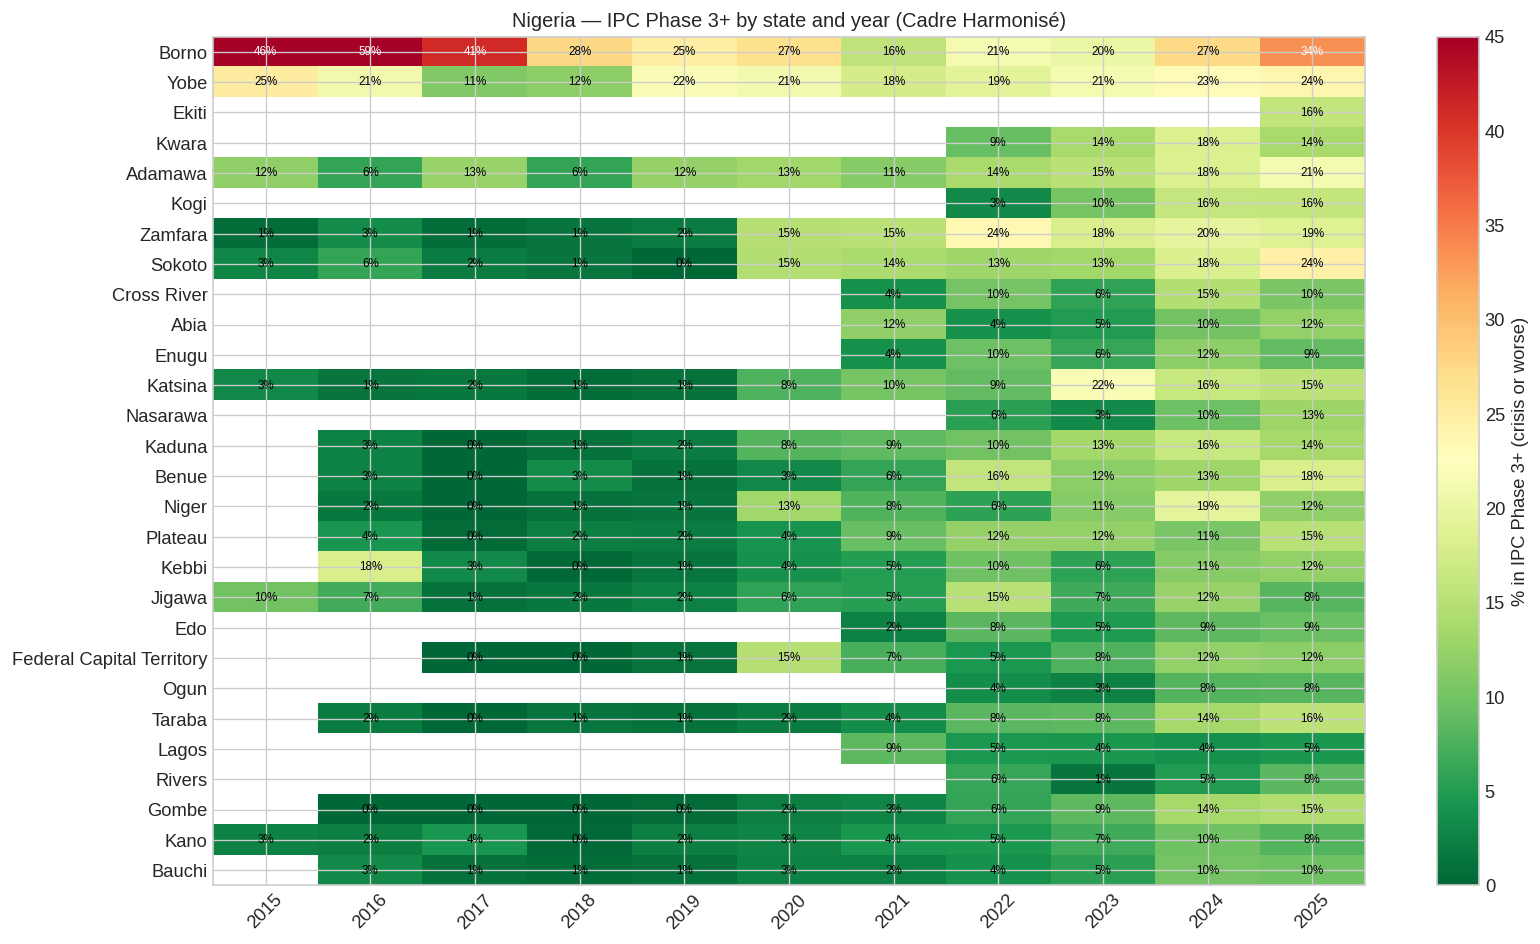

In [7]:
def build_ipc_targets(df_ch: pd.DataFrame) -> pd.DataFrame:
    curr = df_ch[
        (df_ch['chtype'] == 'current') &
        (df_ch['usethisperiod'] == 'Y')
    ].copy()

    agg = curr.groupby(['adm1_name', 'exercise_year', 'exercise_label']).agg(
        population = ('population', 'sum'),
        phase35    = ('phase35',    'sum'),
        phase4     = ('phase4',     'sum'),
        phase5     = ('phase5',     'sum'),
    ).reset_index()

    agg['phase35_pct'] = agg['phase35'] / agg['population'] * 100
    agg['phase4_pct']  = (agg['phase4'] + agg['phase5']) / agg['population'] * 100

    # When multiple periods per year: keep the one with highest population coverage
    return (
        agg.sort_values('population', ascending=False)
           .groupby(['adm1_name', 'exercise_year'])
           .first()
           .reset_index()
    )


ipc_targets = build_ipc_targets(df_ch_nga)
print(f'{len(ipc_targets)} state-year records')

# Visualise IPC heatmap
pivot = ipc_targets.pivot_table(
    index='adm1_name', columns='exercise_year',
    values='phase35_pct', aggfunc='mean'
)
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=45)
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=45)
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.0f}%', ha='center', va='center',
                    fontsize=7, color='black' if v < 30 else 'white')
plt.colorbar(im, ax=ax, label='% in IPC Phase 3+ (crisis or worse)')
ax.set_title('Nigeria — IPC Phase 3+ by state and year (Cadre Harmonisé)', fontsize=12)
plt.tight_layout()
plt.show()

## Step 5 — Feature engineering

| Feature type | What it encodes |
|---|---|
| `mean_X`, `std_X` | Average price and volatility for commodity group X |
| `X_lag1`, `X_lag2` | Price from 1 and 2 years ago — hunger follows shocks with a delay |
| `X_yoy` | Year-on-year % change — captures acceleration, not just level |
| `X_national_idx` | Price relative to national mean — preserves Borno vs Lagos differences |

In [8]:
# Annual mean and std price per state × commodity group
annual_raw = (
    df_wfp_clean
    .groupby(['admin1', 'year', 'commodity_group'])['price']
    .agg(mean='mean', std='std')
    .reset_index()
)

# Pivot to one row per state × year
annual_wide = annual_raw.pivot_table(
    index=['admin1', 'year'], columns='commodity_group',
    values=['mean', 'std'], aggfunc='first'
).reset_index()
annual_wide.columns = [
    '_'.join(filter(None, map(str, c))).strip('_')
    if isinstance(c, tuple) else c
    for c in annual_wide.columns
]
annual_wide = annual_wide.sort_values(['admin1', 'year']).reset_index(drop=True)

price_cols   = [c for c in annual_wide.columns if c not in ['admin1', 'year']]
feat         = annual_wide.copy()
overall_mean = feat[price_cols].mean()

for col in price_cols:
    grp = feat.groupby('admin1')[col]
    feat[f'{col}_lag1']         = grp.shift(1)
    feat[f'{col}_lag2']         = grp.shift(2)
    feat[f'{col}_yoy']          = grp.transform(lambda x: x.pct_change(1) * 100)
    feat[f'{col}_national_idx'] = feat[col] / overall_mean[col]

if 'mean_staples' in feat.columns and 'mean_legumes' in feat.columns:
    feat['ratio_legumes_staples'] = (
        feat['mean_legumes'] / feat['mean_staples'].replace(0, np.nan)
    )

feat = feat.replace([np.inf, -np.inf], np.nan)  # infinity from div-by-zero in YoY
print(f'Feature matrix: {len(feat)} state-year rows × {feat.shape[1]} columns')

Feature matrix: 194 state-year rows × 63 columns


## Step 6 — Merge price features with IPC targets

In [9]:
feat['admin1_clean']      = feat['admin1'].str.strip().str.title()
ipc_targets['adm1_clean'] = ipc_targets['adm1_name'].str.strip().str.title()

model_df = pd.merge(
    feat,
    ipc_targets[['adm1_clean', 'exercise_year', 'phase35_pct', 'phase4_pct']],
    left_on  = ['admin1_clean', 'year'],
    right_on = ['adm1_clean',   'exercise_year'],
    how      = 'inner'
)

print(f'Merged: {len(model_df)} rows | {model_df["admin1"].nunique()} states | '
      f'years {sorted(model_df["year"].unique())}')
print(f'Phase 3+ range: {model_df["phase35_pct"].min():.1f}% – '
      f'{model_df["phase35_pct"].max():.1f}%  |  mean {model_df["phase35_pct"].mean():.1f}%')

Merged: 103 rows | 13 states | years [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
Phase 3+ range: 0.0% – 59.3%  |  mean 10.6%


## Step 7 — Prepare model matrix (handle missing values)

In [10]:
TARGET  = 'phase35_pct'
EXCLUDE = ['admin1', 'admin1_clean', 'adm1_clean', 'exercise_year',
           TARGET, 'phase4_pct', 'year']

X_cols_all = [c for c in model_df.columns
              if c not in EXCLUDE
              and model_df[c].dtype in [float, np.float64, int, np.int64]]

# Drop columns with >50% missing (protein is sparsely reported)
null_rates = model_df[X_cols_all].isnull().mean()
X_cols     = null_rates[null_rates <= 0.50].index.tolist()
print(f'Features: {len(X_cols_all)} total → {len(X_cols)} after removing sparse columns')

# Impute remaining NaNs with column median
# (lag features are blank in a state's first year — impute rather than discard the row)
model_clean = model_df[X_cols + [TARGET, 'year', 'admin1']].dropna(subset=[TARGET]).copy()
imputer     = SimpleImputer(strategy='median')
model_clean[X_cols] = imputer.fit_transform(model_clean[X_cols])
model_clean = model_clean.sort_values(['year', 'admin1']).reset_index(drop=True)

X      = model_clean[X_cols].values
y      = model_clean[TARGET].values
years  = model_clean['year'].values
states = model_clean['admin1'].values

print(f'\nModel matrix: {X.shape[0]} rows × {X.shape[1]} features')
print(f'NaN: {np.isnan(X).sum()}  Inf: {np.isinf(X).sum()}  — both must be 0 to proceed')

Features: 61 total → 51 after removing sparse columns

Model matrix: 103 rows × 51 features
NaN: 0  Inf: 0  — both must be 0 to proceed


## Step 8 — Train models with Leave-One-Year-Out cross-validation

**Why not a random train/test split?**
With time-series data, randomly splitting lets the model see 2020 during training and then predict 2019 — it's effectively predicting the past. LOYO CV holds out one year at a time and always trains only on other years, giving honest out-of-sample predictions.

In [11]:
logo = LeaveOneGroupOut()

rf_model  = RandomForestRegressor(
    n_estimators=300, max_depth=6, min_samples_leaf=2,
    random_state=42, n_jobs=-1
)
xgb_model = xgb.XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, verbosity=0
)

rf_preds  = np.zeros(len(y))
xgb_preds = np.zeros(len(y))

for tr_idx, te_idx in logo.split(X, y, groups=years):
    rf_model.fit(X[tr_idx],  y[tr_idx])
    xgb_model.fit(X[tr_idx], y[tr_idx])
    rf_preds[te_idx]  = rf_model.predict(X[te_idx])
    xgb_preds[te_idx] = xgb_model.predict(X[te_idx])

ensemble = np.clip((rf_preds + xgb_preds) / 2, 0, 100)
print(f'Training complete. {len(np.unique(years))} LOYO folds.')

Training complete. 11 LOYO folds.


## Step 9 — Evaluate model performance

In [12]:
def report_metrics(name, y_true, y_pred):
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)
    smape = np.mean(2 * np.abs(y_true - y_pred) /
                    (np.abs(y_true) + np.abs(y_pred) + 1e-6)) * 100
    print(f'  {name:<22}  MAE={mae:.2f}pp  RMSE={rmse:.2f}pp  '
          f'R²={r2:.3f}  sMAPE={smape:.1f}%')
    return mae, rmse, r2

print('=== LOYO Cross-Validation Performance ===\n')
report_metrics('Random Forest',   y, rf_preds)
report_metrics('XGBoost',         y, xgb_preds)
report_metrics('Ensemble (avg)',  y, ensemble)

print(f'\nMAE interpretation: on average, the ensemble predicts a state\'s')
print(f'Phase 3+ level within ±{mean_absolute_error(y, ensemble):.1f} percentage points.')

# Per-state breakdown
results = model_clean[['admin1', 'year', TARGET]].copy()
results['predicted'] = ensemble
results['error_pp']  = (ensemble - y).round(1)

per_state = results.groupby('admin1').apply(
    lambda g: pd.Series({
        'actual_mean%':    round(g[TARGET].mean(), 1),
        'predicted_mean%': round(g['predicted'].mean(), 1),
        'MAE_pp':          round(mean_absolute_error(g[TARGET], g['predicted']), 1),
        'years':           len(g),
    })
).sort_values('actual_mean%', ascending=False)

print('\n=== Per-State Performance ===')
print(per_state.to_string())

=== LOYO Cross-Validation Performance ===

  Random Forest           MAE=6.76pp  RMSE=9.62pp  R²=0.176  sMAPE=75.9%
  XGBoost                 MAE=7.86pp  RMSE=11.89pp  R²=-0.258  sMAPE=77.4%
  Ensemble (avg)          MAE=7.24pp  RMSE=10.56pp  R²=0.007  sMAPE=76.8%

MAE interpretation: on average, the ensemble predicts a state's
Phase 3+ level within ±7.2 percentage points.

=== Per-State Performance ===
         actual_mean%  predicted_mean%  MAE_pp  years
admin1                                               
Borno            31.3             19.2    13.9   11.0
Yobe             19.7             17.3     5.3   11.0
Adamawa          12.9             17.5     7.6   11.0
Zamfara           8.8              9.5     6.0    9.0
Abia              7.0             11.5     5.5    3.0
Katsina           6.3              8.3     4.0    9.0
Jigawa            6.1              7.7     5.0    9.0
Kebbi             6.0             15.2     9.4    8.0
Lagos             5.9             13.0     7.0    3.0

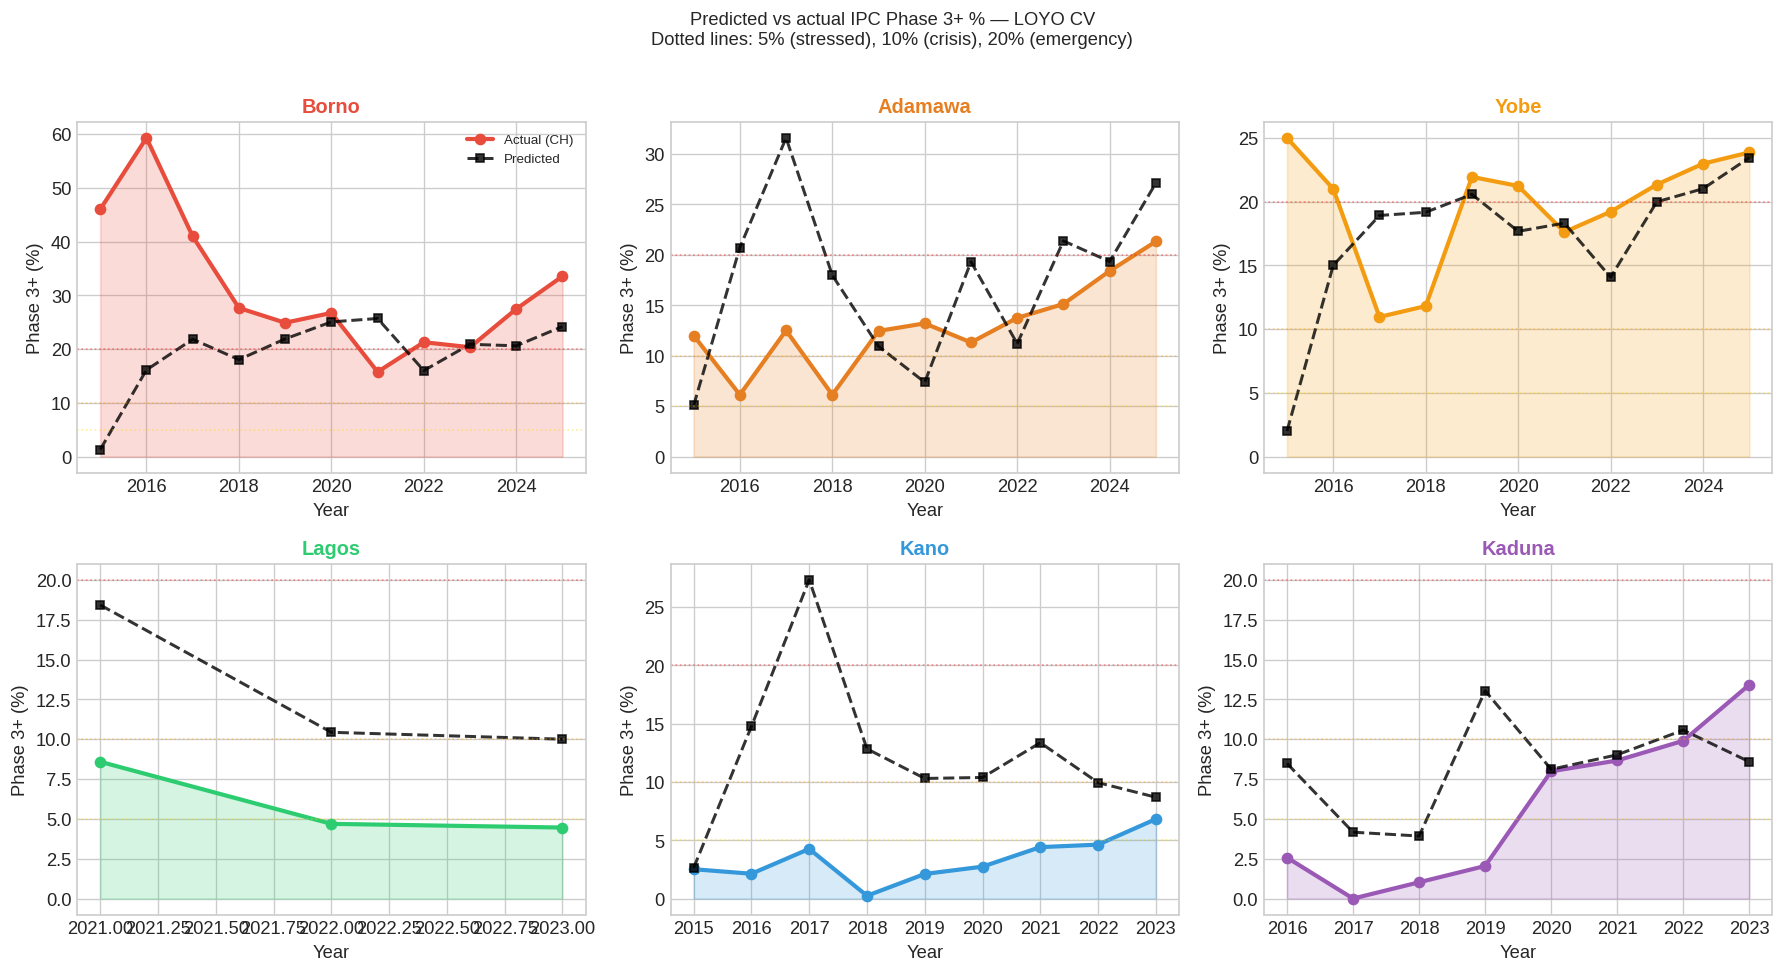

In [13]:
# Predicted vs actual — six key states
focus_states = ['Borno', 'Adamawa', 'Yobe', 'Lagos', 'Kano', 'Kaduna']
colors = {'Borno':'#e74c3c','Adamawa':'#e67e22','Yobe':'#f39c12',
          'Lagos':'#2ecc71','Kano':'#3498db','Kaduna':'#9b59b6'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, state in enumerate(focus_states):
    s  = results[results['admin1'] == state].sort_values('year')
    ax = axes[i]; col = colors[state]
    ax.fill_between(s['year'], 0, s[TARGET], alpha=0.2, color=col)
    ax.plot(s['year'], s[TARGET],    'o-',  color=col,   linewidth=2.5, markersize=6, label='Actual (CH)')
    ax.plot(s['year'], s['predicted'],'s--', color='black', linewidth=1.8, markersize=5, alpha=0.8, label='Predicted')
    ax.axhline(20, color='red',    linestyle=':', alpha=0.4, linewidth=1)
    ax.axhline(10, color='orange', linestyle=':', alpha=0.4, linewidth=1)
    ax.axhline(5,  color='gold',   linestyle=':', alpha=0.4, linewidth=1)
    ax.set_title(state, fontweight='bold', color=col, fontsize=12)
    ax.set_ylabel('Phase 3+ (%)')
    ax.set_xlabel('Year')
    if i == 0: ax.legend(fontsize=8)

plt.suptitle('Predicted vs actual IPC Phase 3+ % — LOYO CV\n'
             'Dotted lines: 5% (stressed), 10% (crisis), 20% (emergency)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## Step 10 — Feature importance

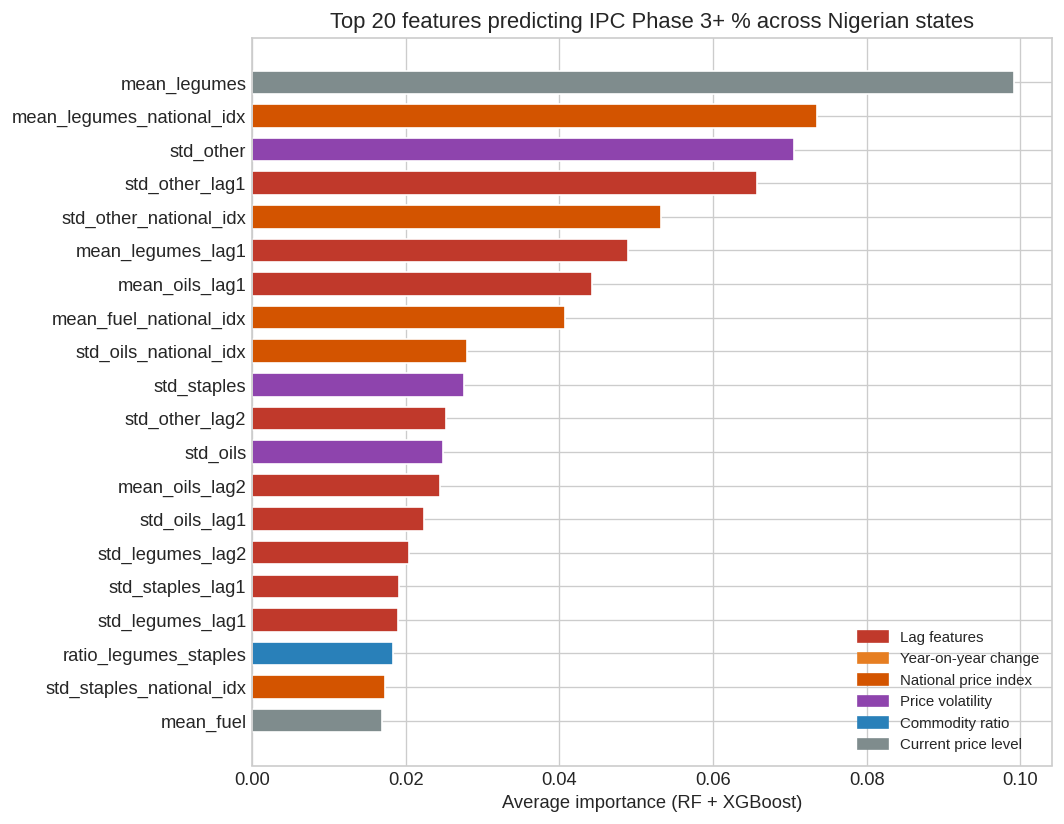

Top 10 predictors:
  mean_legumes                                   0.0992
  mean_legumes_national_idx                      0.0736
  std_other                                      0.0706
  std_other_lag1                                 0.0658
  std_other_national_idx                         0.0533
  mean_legumes_lag1                              0.0490
  mean_oils_lag1                                 0.0442
  mean_fuel_national_idx                         0.0408
  std_oils_national_idx                          0.0280
  std_staples                                    0.0275


In [17]:
# Retrain on all data for importance scores
rf_full  = RandomForestRegressor(n_estimators=300, max_depth=6,
                                  min_samples_leaf=2, random_state=42)
xgb_full = xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              reg_alpha=0.1, reg_lambda=1.0,
                              random_state=42, verbosity=0)
rf_full.fit(X, y)
xgb_full.fit(X, y)

rf_imp   = pd.Series(rf_full.feature_importances_,  index=X_cols)
xgb_imp  = pd.Series(xgb_full.feature_importances_, index=X_cols)
avg_imp  = ((rf_imp / rf_imp.sum()) + (xgb_imp / xgb_imp.sum())) / 2
top20    = avg_imp.nlargest(20).sort_values()

def feat_color(n):
    if 'lag'          in n: return '#c0392b'
    if 'yoy'          in n: return '#e67e22'
    if 'national_idx' in n: return '#d35400'
    if 'std'          in n: return '#8e44ad'
    if 'ratio'        in n: return '#2980b9'
    return '#7f8c8d'

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20.index, top20.values,
        color=[feat_color(n) for n in top20.index],
        edgecolor='white', height=0.7)
legend_els = [
    mpatches.Patch(color='#c0392b', label='Lag features'),
    mpatches.Patch(color='#e67e22', label='Year-on-year change'),
    mpatches.Patch(color='#d35400', label='National price index'),
    mpatches.Patch(color='#8e44ad', label='Price volatility'),
    mpatches.Patch(color='#2980b9', label='Commodity ratio'),
    mpatches.Patch(color='#7f8c8d', label='Current price level'),
]
ax.legend(handles=legend_els, fontsize=9)
ax.set_xlabel('Average importance (RF + XGBoost)')
ax.set_title('Top 20 features predicting IPC Phase 3+ % across Nigerian states')
plt.tight_layout()
plt.show()

print('Top 10 predictors:')
for f, imp in avg_imp.nlargest(10).items():
    print(f'  {f:<45}  {imp:.4f}')

## Step 11 — Early warning alerts

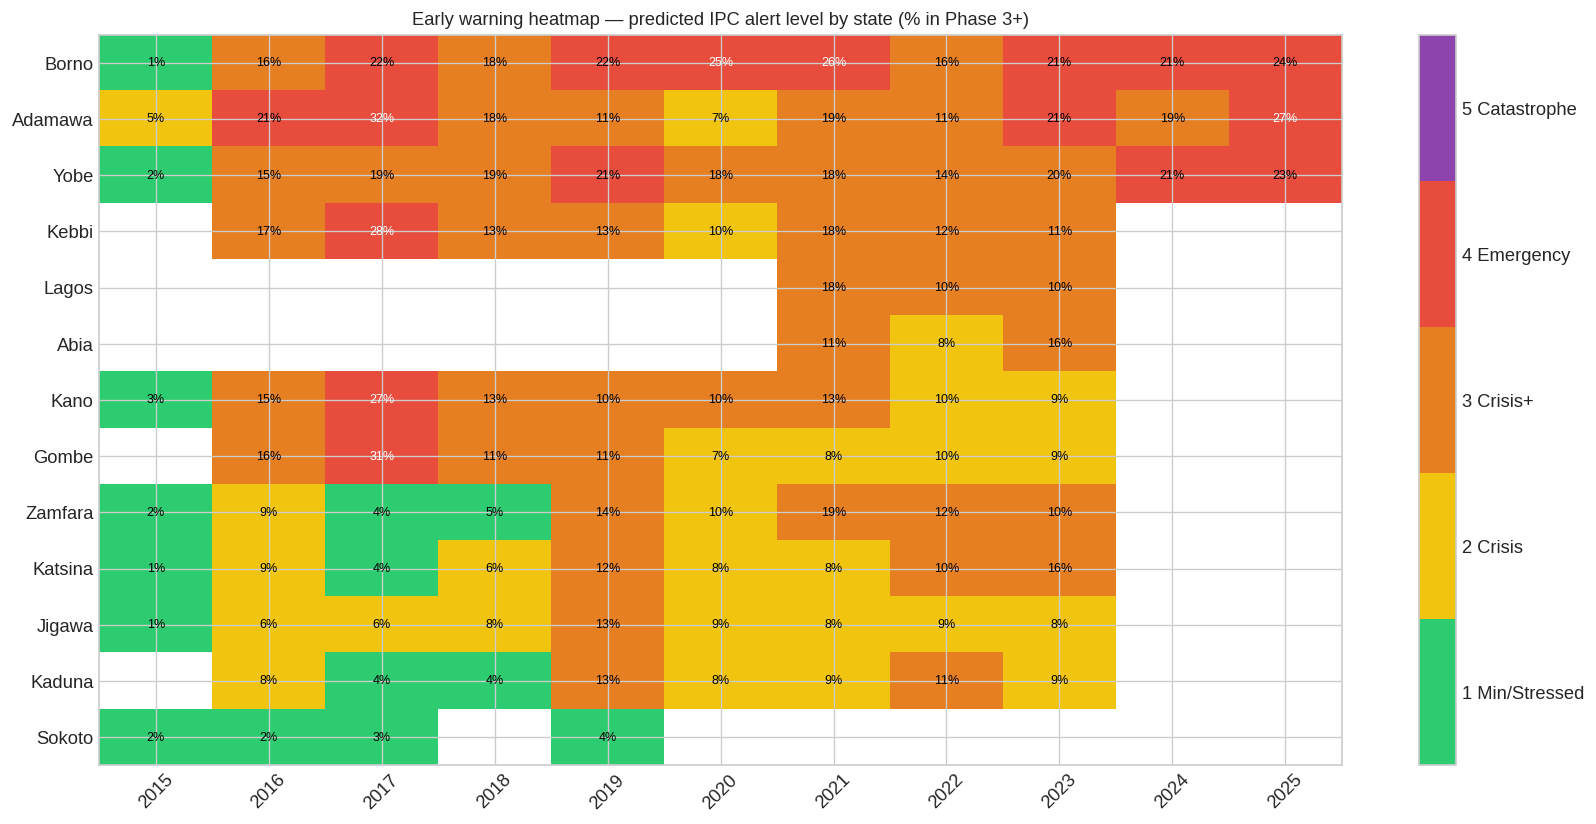


=== 2025 State Alerts ===
State          Pred%  Actual%  Alert
-------------------------------------------------------
Adamawa        27.1%    21.3%  Phase 4    Emergency
Borno          24.2%    33.5%  Phase 4    Emergency
Yobe           23.4%    23.9%  Phase 4    Emergency


In [18]:
def ipc_alert(pct):
    if pct < 5:   return (1, 'Phase 1-2  Minimal/Stressed', '#2ecc71')
    if pct < 10:  return (2, 'Phase 3    Crisis-monitor',    '#f1c40f')
    if pct < 20:  return (3, 'Phase 3+   Crisis-intervene',  '#e67e22')
    if pct < 35:  return (4, 'Phase 4    Emergency',          '#e74c3c')
    return              (5, 'Phase 5    Catastrophe',         '#8e44ad')

results['alert_level']  = results['predicted'].apply(lambda x: ipc_alert(x)[0])
results['alert_label']  = results['predicted'].apply(lambda x: ipc_alert(x)[1])
results['alert_colour'] = results['predicted'].apply(lambda x: ipc_alert(x)[2])

# Alert heatmap
alert_pivot = results.pivot_table(
    index='admin1', columns='year', values='alert_level', aggfunc='mean'
)
alert_pivot = alert_pivot.loc[
    alert_pivot.mean(axis=1).sort_values(ascending=False).index
]
pred_pivot = results.pivot_table(
    index='admin1', columns='year', values='predicted', aggfunc='mean'
).reindex(alert_pivot.index)

cmap = ListedColormap(['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad'])
norm = BoundaryNorm([0.5,1.5,2.5,3.5,4.5,5.5], cmap.N)

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(alert_pivot.values, aspect='auto', cmap=cmap, norm=norm)
ax.set_xticks(range(len(alert_pivot.columns))); ax.set_xticklabels(alert_pivot.columns, rotation=45)
ax.set_yticks(range(len(alert_pivot.index)));   ax.set_yticklabels(alert_pivot.index)
for i in range(len(alert_pivot.index)):
    for j in range(len(alert_pivot.columns)):
        v = pred_pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.0f}%', ha='center', va='center',
                    fontsize=7.5, color='black' if v < 25 else 'white')
cbar = plt.colorbar(im, ax=ax, ticks=[1,2,3,4,5])
cbar.set_ticklabels(['1 Min/Stressed','2 Crisis','3 Crisis+','4 Emergency','5 Catastrophe'])
ax.set_title('Early warning heatmap — predicted IPC alert level by state (% in Phase 3+)', fontsize=11)
plt.tight_layout()
plt.show()

latest_year = int(results['year'].max())
latest = results[results['year']==latest_year].sort_values('predicted',ascending=False)
print(f'\n=== {latest_year} State Alerts ===')
print(f'{"State":<12} {"Pred%":>7} {"Actual%":>8}  Alert')
print('-'*55)
for _, r in latest.iterrows():
    print(f'{r["admin1"]:<12} {r["predicted"]:>6.1f}% {r[TARGET]:>7.1f}%  {r["alert_label"]}')

## Step 12 — Residual analysis and model limitations

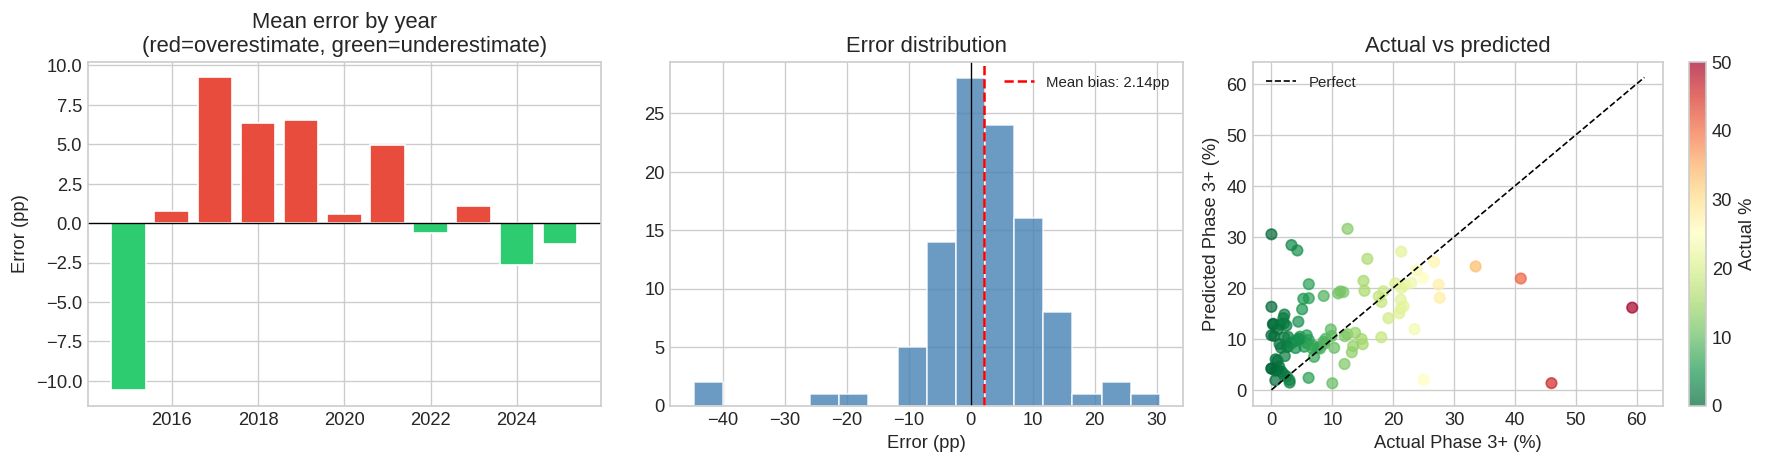

=== Final Model Summary ===
  MAE:        7.24 pp
  RMSE:       10.56 pp
  R²:         0.007
  Mean bias:  +2.14 pp

  Known limitation: Borno 2015-2016 is underestimated because
  lag features have no prior-year price data for those early rows.
  This would improve as more historical WFP data is added.


In [15]:
results['residual'] = results['predicted'] - results[TARGET]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

res_yr = results.groupby('year')['residual'].mean()
axes[0].bar(res_yr.index, res_yr.values,
            color=['#e74c3c' if r > 0 else '#2ecc71' for r in res_yr.values],
            edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Mean error by year\n(red=overestimate, green=underestimate)')
axes[0].set_ylabel('Error (pp)')

axes[1].hist(results['residual'], bins=16, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].axvline(results['residual'].mean(), color='red', linestyle='--',
                label=f'Mean bias: {results["residual"].mean():.2f}pp')
axes[1].set_title('Error distribution'); axes[1].set_xlabel('Error (pp)')
axes[1].legend(fontsize=9)

sc = axes[2].scatter(results[TARGET], results['predicted'],
                     c=results[TARGET], cmap='RdYlGn_r', s=40, alpha=0.7, vmin=0, vmax=50)
lims = [0, max(results[TARGET].max(), results['predicted'].max()) + 2]
axes[2].plot(lims, lims, 'k--', linewidth=1, label='Perfect')
plt.colorbar(sc, ax=axes[2], label='Actual %')
axes[2].set_xlabel('Actual Phase 3+ (%)'); axes[2].set_ylabel('Predicted Phase 3+ (%)')
axes[2].set_title('Actual vs predicted'); axes[2].legend(fontsize=9)
plt.tight_layout(); plt.show()

mae_f  = mean_absolute_error(results[TARGET], results['predicted'])
rmse_f = np.sqrt(mean_squared_error(results[TARGET], results['predicted']))
r2_f   = r2_score(results[TARGET], results['predicted'])

print('=== Final Model Summary ===')
print(f'  MAE:        {mae_f:.2f} pp')
print(f'  RMSE:       {rmse_f:.2f} pp')
print(f'  R²:         {r2_f:.3f}')
print(f'  Mean bias:  {results["residual"].mean():+.2f} pp')
print(f'\n  Known limitation: Borno 2015-2016 is underestimated because')
print(f'  lag features have no prior-year price data for those early rows.')
print(f'  This would improve as more historical WFP data is added.')

## Step 13 — Save the trained model

In [19]:
model_bundle = {
    'rf':                 rf_full,
    'xgb':                xgb_full,
    'X_cols':             X_cols,
    'imputer':            imputer,
    'overall_mean':       overall_mean,
    'price_cols':         price_cols,
    'cv_results':         results,
    'feature_importance': avg_imp,
}
joblib.dump(model_bundle, 'nigeria_food_insecurity_model.pkl')
print('Saved: nigeria_food_insecurity_model.pkl')
print('\nTo reload:')
print('  import joblib')
print('  bundle = joblib.load("nigeria_food_insecurity_model.pkl")')

Saved: nigeria_food_insecurity_model.pkl

To reload:
  import joblib
  bundle = joblib.load("nigeria_food_insecurity_model.pkl")
